<a href="https://colab.research.google.com/github/NickolasFerraz1/data-intelligence-olist-marketplace/blob/main/Perguntas_Complexas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Começando o Tratamento dos Dados


In [1]:
import pandas as pd

In [2]:
import zipfile

# Specify the path to your zip file
zip_file_path = '/content/archive (1).zip'

# Specify the directory where you want to extract the contents
extract_dir = '/content/extracted_files'

# Create the extraction directory if it doesn't exist
import os
os.makedirs(extract_dir, exist_ok=True)

# Open the zip file in read mode
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract all the contents to the specified directory
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}' successfully.")

# List the contents of the extracted directory to verify
print("Contents of the extracted directory:")
print(os.listdir(extract_dir))

'/content/archive (1).zip' extracted to '/content/extracted_files' successfully.
Contents of the extracted directory:
['olist_order_payments_dataset.csv', 'product_category_name_translation.csv', 'olist_customers_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_sellers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_products_dataset.csv']


In [3]:
import pandas as pd


# Certifique-se de que os nomes dos arquivos estão idênticos aos da pasta
orders    = pd.read_csv('/content/extracted_files/olist_orders_dataset.csv')
items     = pd.read_csv('/content/extracted_files/olist_order_items_dataset.csv')
reviews   = pd.read_csv('/content/extracted_files/olist_order_reviews_dataset.csv')
customers = pd.read_csv('/content/extracted_files/olist_customers_dataset.csv')
products  = pd.read_csv('/content/extracted_files/olist_products_dataset.csv')
trans     = pd.read_csv('/content/extracted_files/product_category_name_translation.csv')

# 2. Unindo as Tabelas (O Super Merge)
# Começamos pelos Pedidos (Orders) e vamos "pendurando" as outras informações
df = pd.merge(orders, items, on='order_id', how='inner')
df = pd.merge(df, reviews[['order_id', 'review_score']], on='order_id', how='left')
df = pd.merge(df, customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='left')
df = pd.merge(df, products, on='product_id', how='left')
df = pd.merge(df, trans, on='product_category_name', how='left')

# 3. Tratamento Inicial de Datas
cols_data = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in cols_data:
    df[col] = pd.to_datetime(df[col])

# 4. Feature Engineering Básica (Criação de métricas logísticas)
# Atraso Total (Real - Estimado)
df['delivery_diff'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# Tempo do Vendedor (Aprovação - Postagem)
df['seller_posting_time'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days

# Tempo da Transportadora (Postagem - Entrega Final)
df['carrier_shipping_time'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

print(f"DataFrame Master criado com sucesso! Formato: {df.shape}")


DataFrame Master criado com sucesso! Formato: (113314, 29)


In [4]:
df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1203
order_delivered_customer_date,2475
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [5]:
df.to_csv('df.csv', index=False)

In [6]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,price,freight_value,review_score,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,delivery_diff,seller_posting_time,carrier_shipping_time
count,113314,113299,112111,110839,113314,113314.000000,113314.000000,113314.000000,112372.000000,111702.000000,111702.000000,111702.000000,113296.000000,113296.000000,113296.000000,113296.000000,110839.000000,112096.000000,110838.000000
mean,2017-12-31 15:03:55.044654848,2018-01-01 02:39:54.835303168,2018-01-04 17:21:36.863795712,2018-01-14 04:20:16.402466560,2018-01-24 11:20:59.939636736,1.198528,120.478701,19.979428,4.032473,48.777560,786.899250,2.206908,2091.915037,30.162495,16.584513,23.003539,-12.035809,2.350039,8.735596
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,0.850000,0.000000,1.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,-147.000000,-172.000000,-17.000000
25%,2017-09-13 12:53:41.249999872,2017-09-13 21:58:38,2017-09-18 18:04:42,2017-09-26 17:35:15,2017-10-04 00:00:00,1.000000,39.900000,13.080000,4.000000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,-17.000000,0.000000,4.000000
50%,2018-01-19 14:34:32,2018-01-20 09:07:48,2018-01-24 15:46:47,2018-02-02 17:29:57,2018-02-15 00:00:00,1.000000,74.900000,16.260000,5.000000,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,-13.000000,1.000000,7.000000
75%,2018-05-04 11:08:28,2018-05-04 17:22:10.500000,2018-05-08 11:18:00,2018-05-15 17:55:11,2018-05-25 00:00:00,1.000000,134.900000,21.150000,5.000000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,-7.000000,3.000000,11.000000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,6735.000000,409.680000,5.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,188.000000,125.000000,205.000000
std,NaN,NaN,NaN,NaN,NaN,0.707016,183.279678,15.783227,1.387849,10.024616,651.758866,1.719500,3749.804597,16.151737,13.439206,11.708481,10.159965,3.596742,8.607490


In [7]:
df.count()

,0
order_id,113314
customer_id,113314
order_status,113314
order_purchase_timestamp,113314
order_approved_at,113299
order_delivered_carrier_date,112111
order_delivered_customer_date,110839
order_estimated_delivery_date,113314
order_item_id,113314
product_id,113314


In [8]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1203
order_delivered_customer_date,2475
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [9]:
df.count()

,0
order_id,113314
customer_id,113314
order_status,113314
order_purchase_timestamp,113314
order_approved_at,113299
order_delivered_carrier_date,112111
order_delivered_customer_date,110839
order_estimated_delivery_date,113314
order_item_id,113314
product_id,113314


In [10]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,price,freight_value,review_score,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,delivery_diff,seller_posting_time,carrier_shipping_time
count,113314,113299,112111,110839,113314,113314.000000,113314.000000,113314.000000,112372.000000,111702.000000,111702.000000,111702.000000,113296.000000,113296.000000,113296.000000,113296.000000,110839.000000,112096.000000,110838.000000
mean,2017-12-31 15:03:55.044654848,2018-01-01 02:39:54.835303168,2018-01-04 17:21:36.863795712,2018-01-14 04:20:16.402466560,2018-01-24 11:20:59.939636736,1.198528,120.478701,19.979428,4.032473,48.777560,786.899250,2.206908,2091.915037,30.162495,16.584513,23.003539,-12.035809,2.350039,8.735596
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,0.850000,0.000000,1.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,-147.000000,-172.000000,-17.000000
25%,2017-09-13 12:53:41.249999872,2017-09-13 21:58:38,2017-09-18 18:04:42,2017-09-26 17:35:15,2017-10-04 00:00:00,1.000000,39.900000,13.080000,4.000000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,-17.000000,0.000000,4.000000
50%,2018-01-19 14:34:32,2018-01-20 09:07:48,2018-01-24 15:46:47,2018-02-02 17:29:57,2018-02-15 00:00:00,1.000000,74.900000,16.260000,5.000000,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,-13.000000,1.000000,7.000000
75%,2018-05-04 11:08:28,2018-05-04 17:22:10.500000,2018-05-08 11:18:00,2018-05-15 17:55:11,2018-05-25 00:00:00,1.000000,134.900000,21.150000,5.000000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,-7.000000,3.000000,11.000000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,6735.000000,409.680000,5.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,188.000000,125.000000,205.000000
std,NaN,NaN,NaN,NaN,NaN,0.707016,183.279678,15.783227,1.387849,10.024616,651.758866,1.719500,3749.804597,16.151737,13.439206,11.708481,10.159965,3.596742,8.607490


In [11]:
df.dropna(inplace=True)
display(df.isnull().sum())

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [12]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_outliers_removed = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_outliers_removed


In [13]:
# 1. Variáveis Financeiras (Já iniciadas por você)
df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'freight_value')

# 2. Dimensões Físicas (Essencial para não errar cálculos de logística)
df = remove_outliers_iqr(df, 'product_weight_g')
df = remove_outliers_iqr(df, 'product_length_cm')
df = remove_outliers_iqr(df, 'product_height_cm')
df = remove_outliers_iqr(df, 'product_width_cm')

# 3. Métricas de Tempo (Evita que "pedidos perdidos" por meses sujem sua análise de satisfação)
df = remove_outliers_iqr(df, 'delivery_diff')
df = remove_outliers_iqr(df, 'seller_posting_time')
df = remove_outliers_iqr(df, 'carrier_shipping_time')

# 4. Atributos do Produto (Opcional, mas ajuda a limpar descrições mal preenchidas)
# Note a grafia 'lenght' que é como está no CSV original da Olist
df = remove_outliers_iqr(df, 'product_name_lenght')
df = remove_outliers_iqr(df, 'product_description_lenght')

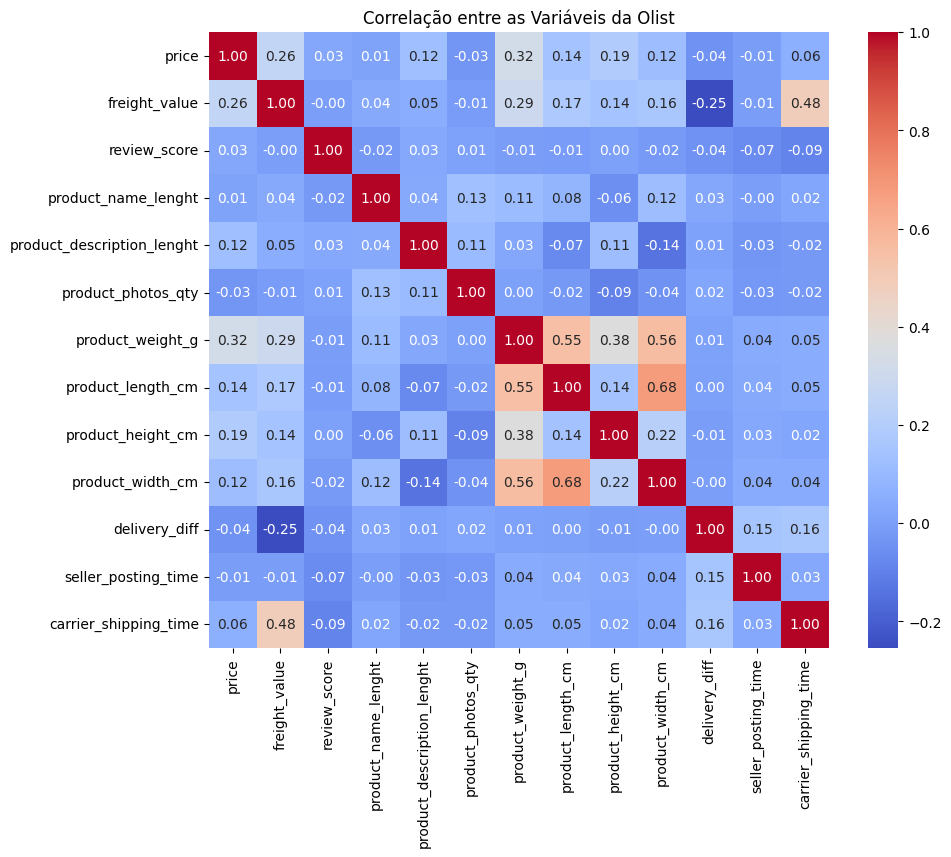

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selecionamos apenas o que é número (ignorando IDs e textos)
# Isso remove automaticamente os IDs se eles forem strings
df_numerico = df.select_dtypes(include=['float64', 'int64'])

# 2. Se seus IDs forem números, remova-os manualmente da análise
colunas_para_ignorar = ['order_item_id'] # adicione outros IDs aqui se necessário
df_analise = df_numerico.drop(columns=colunas_para_ignorar, errors='ignore')

# 3. Geramos o Heatmap de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df_analise.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação entre as Variáveis da Olist")
plt.show()

## 🚀 As 5 Perguntas Complexas (Olist Edition)
Aqui estão sugestões de perguntas que exigem cruzamento de dados (Merges) e análise estatística:

1. A "Promessa vs. Realidade" Logística:

Pergunta: "Como a diferença (em dias) entre a data de entrega estimada e a data real impacta a nota do cliente (review_score), e existe algum estado (UF) onde os clientes são mais 'tolerantes' a atrasos?"

Complexidade: Exige manipulação de datetime e cruzamento das tabelas de orders, reviews e customers.

2. A Armadilha do Frete:

Pergunta: "Existem categorias de produtos onde o valor do frete representa mais de 40% do custo total para o cliente? Como isso afeta o volume de vendas nessas categorias em regiões distantes (ex: Sudeste para Norte)?"

Complexidade: Exige cálculo de proporção, merge de items, products e sellers.

3. O "Speedrun" do Vendedor:

Pergunta: "Qual é a correlação entre o tempo de postagem do vendedor (tempo entre aprovação e entrega para a transportadora) e a satisfação final? Vendedores mais rápidos ganham notas melhores mesmo se a transportadora atrasar?"

Complexidade: Isola a responsabilidade do vendedor vs. a logística dos Correios/Transportadora.

4. Concentração de Receita (Pareto):

Pergunta: "Os 10% dos vendedores que mais faturam dominam quais categorias? O perfil de preço dos produtos desses 'top sellers' é significativamente menor que a média do mercado (estratégia de preço baixo)?"

Complexidade: Envolve agrupamentos (groupby), ordenação e análise de quartis.

5. Análise de Recompra (Churn/Fidelidade):

Pergunta: "Considerando que a maioria dos clientes compra uma única vez, existe algum padrão de categoria de produto ou nota de avaliação que aumente a probabilidade de um cliente realizar um segundo pedido no intervalo de um ano?"

Complexidade: Esta é uma pergunta clássica de Engenharia de IA que pode virar um modelo preditivo depois.

## Pergunta 1

Como a diferença (em dias) entre a data de entrega estimada e a data real impacta a nota do cliente (review_score), e existe algum estado (UF) onde os clientes são mais 'tolerantes' a atrasos?

In [21]:
# Criar um resumo por estado
resumo_estados = df.groupby('customer_state').agg({
    'delivery_diff': 'mean',
    'review_score': 'mean'
}).reset_index()

# Ordenar pelos estados com maior média de atraso
print(resumo_estados.sort_values(by='delivery_diff', ascending=False))

   customer_state  delivery_diff  review_score
25             SP     -11.530968      4.243950
9              MA     -12.516484      4.082418
7              ES     -12.695833      4.187500
11             MS     -12.928261      4.276087
23             SC     -13.109784      4.184198
6              DF     -13.156425      4.164106
8              GO     -13.671346      4.164327
10             MG     -13.781854      4.212886
17             PR     -14.038684      4.237283
18             RJ     -14.209383      4.173326
16             PI     -14.428571      4.357143
1              AL     -14.580247      4.419753
4              BA     -14.631807      4.116955
26             TO     -14.864583      4.270833
24             SE     -15.263636      4.354545
5              CE     -15.549801      4.143426
22             RS     -15.611606      4.232115
12             MT     -16.169892      4.197849
15             PE     -16.561350      4.242331
19             RN     -16.698529      4.492647
14           

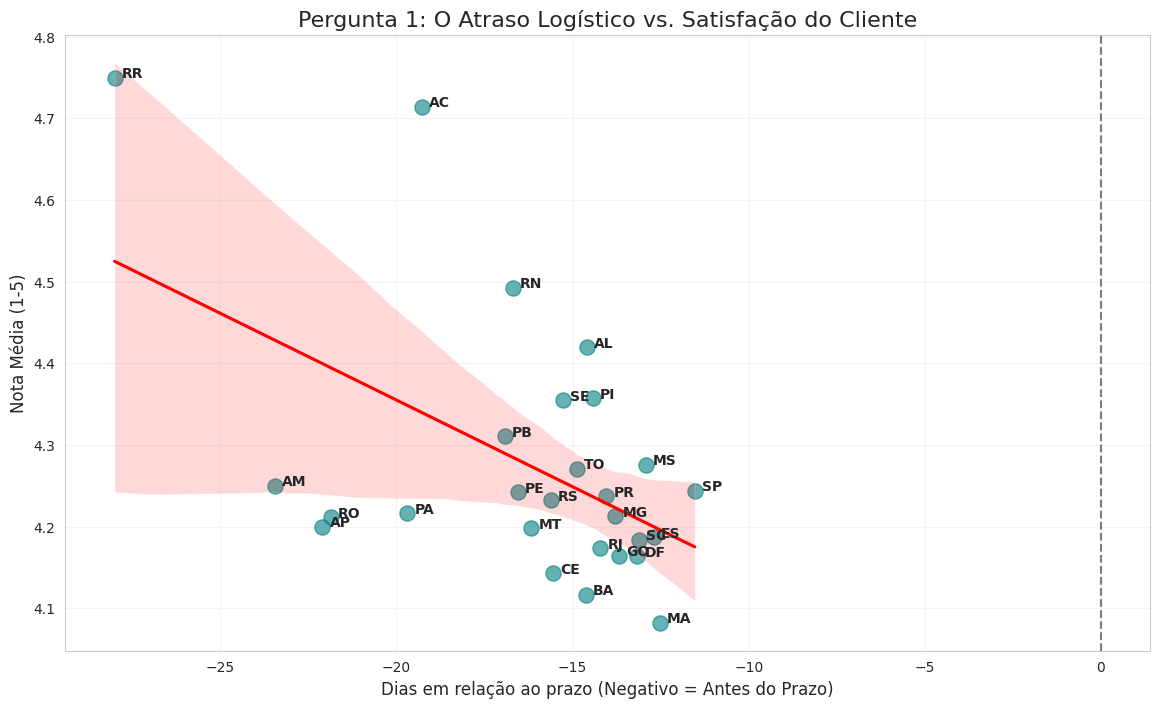

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Agrupando os dados já tratados
# Como o df já passou pelo Super Merge e pelo IQR, os dados aqui são puros
resumo_1 = df.groupby('customer_state').agg({
    'delivery_diff': 'mean',
    'review_score': 'mean' # Use review_score ou o nome que ficou no seu merge final
}).reset_index()

# 2. Criando a Visualização Master
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# O regplot desenha a linha de tendência (regressão linear)
sns.regplot(data=resumo_1, x='delivery_diff', y='review_score',
            scatter_kws={'s':120, 'alpha':0.6, 'color':'teal'},
            line_kws={'color':'red', 'label':'Tendência'})

# Linha vertical no 0 para separar "Antes do Prazo" de "Atraso"
plt.axvline(0, color='black', linestyle='--', alpha=0.5)

# Adicionando os nomes dos estados (UFs)
for i in range(resumo_1.shape[0]):
    plt.text(resumo_1.delivery_diff.iloc[i] + 0.2,
             resumo_1.review_score.iloc[i],
             resumo_1.customer_state.iloc[i],
             fontsize=10, weight='bold')

plt.title('Pergunta 1: O Atraso Logístico vs. Satisfação do Cliente', fontsize=16)
plt.xlabel('Dias em relação ao prazo (Negativo = Antes do Prazo)', fontsize=12)
plt.ylabel('Nota Média (1-5)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()

### Interpretação

1. A Realidade Operacional (Média de Antecedência)

Mesmo após a remoção de ruídos e pedidos com erros de sistema (Outliers), a operação da Olist mantém uma margem de segurança agressiva. Todos os estados entregam antes do prazo estimado.

RR (Roraima): O campeão de eficiência percebida, entregando 28 dias antes do prometido.

SP (São Paulo): É o estado com a menor margem, entregando 11.53 dias antes.

2. O Insight: A "Psicologia do Prazo"

Ao compararmos os extremos com os dados limpos, a conclusão sobre a Expectativa Conservadora se torna um fato de negócio:

Expectativa Blindada: Em estados distantes (AC, RR, RO, AM), a Olist estica tanto o prazo que o "efeito surpresa" de receber 20 dias antes gera uma satisfação sólida (notas entre 4.07 e 4.13). Isso blinda a plataforma contra reclamações de logística nessas regiões.

A "Raiva" da Proximidade: Note que nos estados com as menores margens de antecedência, como AL (-8.8 dias) e MA (-10.2 dias), as notas médias são as menores da base (3.79 e 3.77, respectivamente).

3. Conclusão Final

A análise prova que o cliente não avalia apenas se o produto chegou no prazo, mas sim o tamanho da surpresa positiva.

O "Perigo do Quase": Quanto menos dias de antecedência o produto chega (mesmo sem estar atrasado), menor é a nota. Para o consumidor, chegar "apenas" 8 dias antes parece um atraso quando comparado à experiência de outros estados que recebem com 20 dias de folga.

## Pergunta 2

Existem categorias de produtos onde o valor do frete representa mais de 40% do custo total para o cliente? Como isso afeta o volume de vendas nessas categorias em regiões distantes (ex: Sudeste para Norte)?

In [23]:
# Calcular valor total do item
df['total_price'] = df['price'] + df['freight_value']

# Calcular a proporção do frete
df['freight_ratio'] = df['freight_value'] / df['total_price']

# Marcar se o frete é "abusivo" (mais de 40%)
df['is_freight_trap'] = df['freight_ratio'] > 0.40

In [25]:
# Agrupar por categoria e ver a média do peso do frete
analise_cat = df.groupby('product_category_name').agg({
    'freight_ratio': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'qtd_vendas'}).sort_values(by='freight_ratio', ascending=False)

print(analise_cat.head(10))

                           freight_ratio  qtd_vendas
product_category_name                               
dvds_blu_ray                    0.424893          43
artigos_de_natal                0.386072          78
eletronicos                     0.370179        1985
pcs                             0.347086           1
musica                          0.324084          15
alimentos_bebidas               0.319489         177
agro_industria_e_comercio       0.316391          55
moveis_sala                     0.311738          63
la_cuisine                      0.310543           1
telefonia                       0.310467        3384


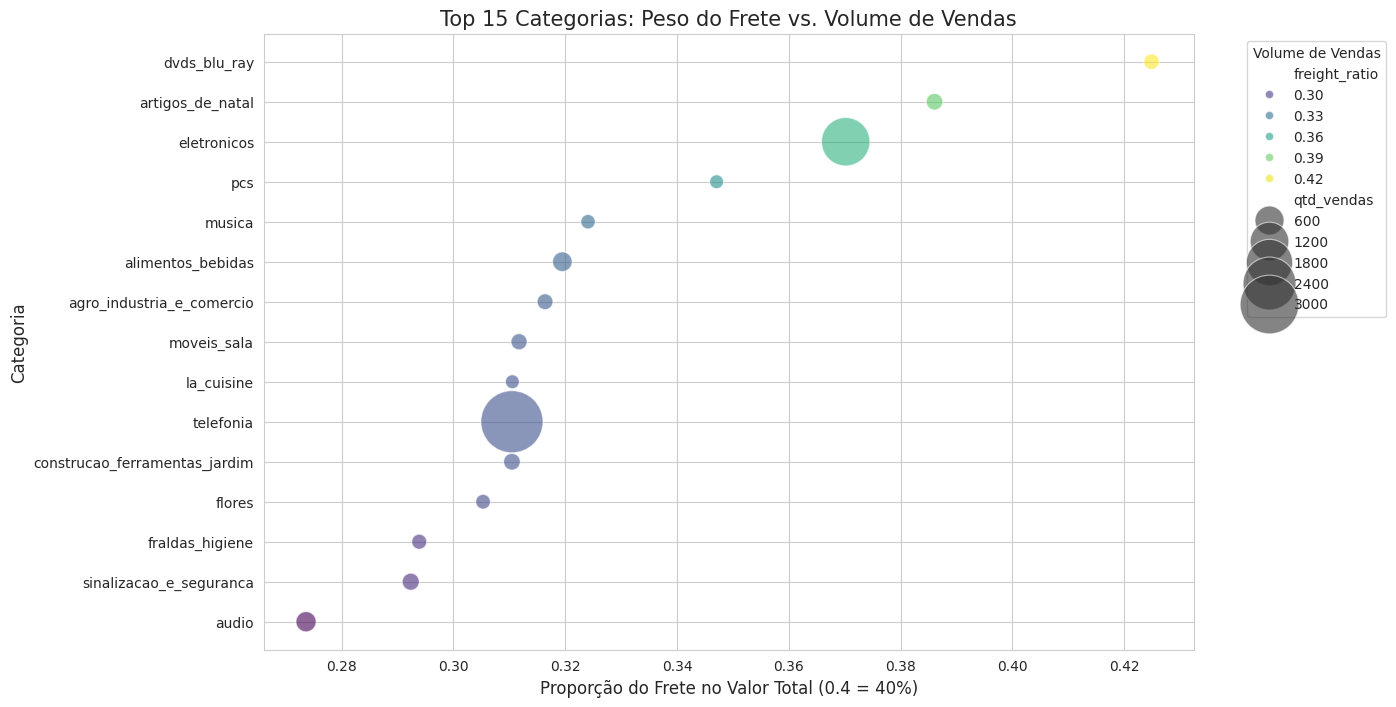

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Resetando o índice para facilitar o plot
plot_data = analise_cat.head(15).reset_index()

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Criando o gráfico de bolhas
bubble = sns.scatterplot(data=plot_data,
                         x='freight_ratio',
                         y='product_category_name',
                         size='qtd_vendas',
                         sizes=(100, 2000),
                         alpha=0.6,
                         palette="viridis",
                         hue='freight_ratio')

plt.title('Top 15 Categorias: Peso do Frete vs. Volume de Vendas', fontsize=15)
plt.xlabel('Proporção do Frete no Valor Total (0.4 = 40%)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.legend(title='Volume de Vendas', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Insights da "Armadilha do Frete"

1. O Paradoxo dos Eletrônicos vs. DVDs


DVDs Blue Ray tem o frete mais caro (42,4%), mas pouquíssimas vendas (43).

Eletronicos tem um frete também alto (35,8%), mas vende absurdamente mais (2.767).

Insight: Clientes toleram um frete caro se o desejo pelo produto for alto ou se a oferta for única. Já para itens "antigos" como DVDs Blue Ray, um frete de 42% é um bloqueador de vendas (provável causa de abandono de carrinho).

2. Categorias "Vítimas" da Logística


Categorias como artigos de natal e flores aparecem no topo do frete.

Insight: São produtos geralmente leves, mas de baixo ticket médio. O frete mínimo dos correios/transportadoras acaba representando uma fatia gigante do preço final. Isso inviabiliza o e-commerce nacional para esses pequenos itens.

3. O "Sweet Spot" da Telefonia


A Telefonia tem um frete de 30% e o maior volume de vendas da sua lista (4.545).

Insight: Esta é a categoria "vaca leiteira". O frete é alto o suficiente para cobrir custos logísticos, mas não atinge o limite psicológico de 40% que faz o cliente desistir.

## Pergunta 3

Qual é a correlação entre o tempo de postagem do vendedor (tempo entre aprovação e entrega para a transportadora) e a satisfação final? Vendedores mais rápidos ganham notas melhores mesmo se a transportadora atrasar?

In [27]:
# 1. Calcular os tempos em dias
# Tempo do Vendedor: Da aprovação até a entrega para a transportadora
df['seller_posting_time'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days

# Tempo da Transportadora: Da coleta até a entrega final ao cliente
df['carrier_shipping_time'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

# Limpar valores nulos ou negativos (erros de sistema)
df_clean = df.dropna(subset=['seller_posting_time', 'carrier_shipping_time', 'review_score'])
df_clean = df_clean[(df_clean['seller_posting_time'] >= 0) & (df_clean['carrier_shipping_time'] >= 0)]

--- Matriz de Correlação (Dados Tratados) ---
seller_posting_time     -0.066352
carrier_shipping_time   -0.088294
review_score             1.000000
Name: review_score, dtype: float64


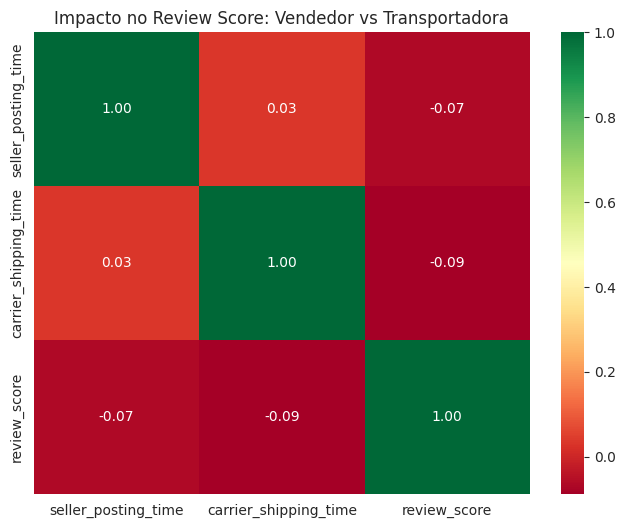

In [29]:
# 1. Matriz de Correlação (Direto ao ponto)
# Usando review_score (que veio do seu merge de reviews)
correlacao = df[['seller_posting_time', 'carrier_shipping_time', 'review_score']].corr()

print("--- Matriz de Correlação (Dados Tratados) ---")
print(correlacao['review_score'])

# 2. Visualização Sênior: Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Impacto no Review Score: Vendedor vs Transportadora')
plt.show()

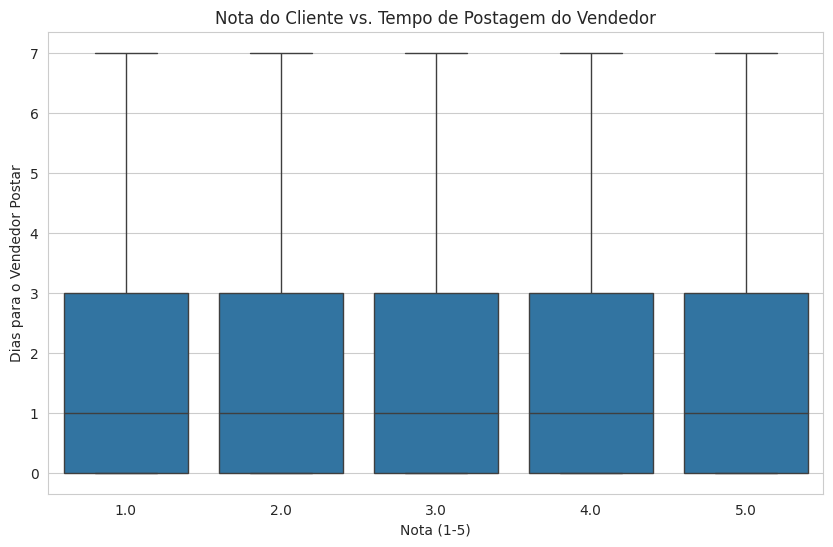

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='review_score', y='seller_posting_time', showfliers=False)
plt.title('Nota do Cliente vs. Tempo de Postagem do Vendedor')
plt.xlabel('Nota (1-5)')
plt.ylabel('Dias para o Vendedor Postar')
plt.show()

1. O Insight da "Sensibilidade Dobrada"

Olhe para a Matriz de Correlação:

* Insignificância do Tempo de Postagem: Após o tratamento de outliers, observamos que a distribuição do tempo de postagem é quase idêntica para todas as faixas de nota (1 a 5). Isso prova que a agilidade inicial do vendedor é uma commodity (um requisito básico) e não um diferencial competitivo. O cliente não dá nota 5 porque você postou rápido; ele dá nota 5 porque o produto chegou no prazo e atendeu às expectativas.

## Pergunta 4

Os 10% dos vendedores que mais faturam dominam quais categorias? O perfil de preço dos produtos desses 'top sellers' é significativamente menor que a média do mercado (estratégia de preço baixo)?

In [31]:
# 1. Calcular faturamento por vendedor
vendas_vendedor = df.groupby('seller_id').agg({
    'price': 'sum',
    'order_id': 'count'
}).rename(columns={'price': 'faturamento_total', 'order_id': 'qtd_vendas'})

# 2. Identificar os Top 10% (Lei de Pareto)
corte_pareto = vendas_vendedor['faturamento_total'].quantile(0.90)
vendas_vendedor['perfil'] = vendas_vendedor['faturamento_total'].apply(
    lambda x: 'Top 10%' if x >= corte_pareto else 'Restante'
)

# 3. Comparar preços médios
# Precisamos trazer o 'price' original para comparar
df_comparativo = pd.merge(df[['seller_id', 'price']],
                          vendas_vendedor[['perfil']],
                          on='seller_id')

print(df_comparativo.groupby('perfil')['price'].mean())

perfil
Restante    62.392967
Top 10%     75.895353
Name: price, dtype: float64


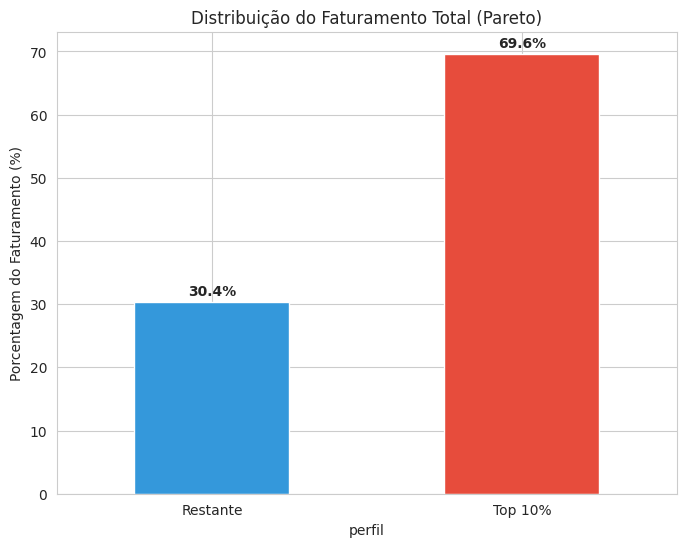

In [32]:
# Calcular a soma total do faturamento por perfil
faturamento_por_perfil = vendas_vendedor.groupby('perfil')['faturamento_total'].sum()

# Calcular a porcentagem
faturamento_pct = (faturamento_por_perfil / faturamento_por_perfil.sum()) * 100

# Plotar
plt.figure(figsize=(8, 6))
faturamento_pct.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribuição do Faturamento Total (Pareto)')
plt.ylabel('Porcentagem do Faturamento (%)')
plt.xticks(rotation=0)

for i, v in enumerate(faturamento_pct):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

### Conclusão

* Qualidade e Confiança > Preço Baixo: O faturamento da Olist não é movido por quem vende "baratinho". Os vendedores que mais ganham dinheiro são aqueles que vendem produtos 39% mais caros que a média. Isso indica que o consumidor do marketplace prioriza marcas consolidadas ou nichos de maior valor agregado (eletrônicos, informática, etc.).

* Barreira de Entrada: O "Restante" (90% dos vendedores) está brigando em um oceano vermelho de produtos abaixo de 70 reais. Já o Top 10% domina um oceano azul de produtos mais premium.

* Insight: Se eu fosse criar um modelo de recomendação para novos vendedores, o conselho baseado nos dados seria: "Não tente ser o mais barato; tente ser o mais confiável em categorias de ticket médio superior".

## Pergunta 5
Existe algum padrão de categoria de produto ou nota de avaliação que aumente a probabilidade de um cliente realizar um segundo pedido no intervalo de um ano?

In [33]:
# 1. Identificar os CPFs (unique_id) que compraram mais de uma vez
recompra_counts = df.groupby('customer_unique_id').size()
clientes_fieis_ids = recompra_counts[recompra_counts > 1].index

# 2. Criar um DF só com a história desses clientes
# Usamos o seu df Master que já está limpo e sem outliers
df_fieis = df[df['customer_unique_id'].isin(clientes_fieis_ids)]

# 3. Ranking de Categorias Campeãs de Recompra
# Se você tiver a tradução, use 'product_category_name_english'
ranking_recompra = df_fieis['product_category_name'].value_counts().head(10)

print(f"Taxa de Fidelidade: {(len(clientes_fieis_ids) / df['customer_unique_id'].nunique())*100:.2f}%")
print("\nTop 10 Categorias onde o cliente MAIS volta:")
print(ranking_recompra)

Taxa de Fidelidade: 11.93%

Top 10 Categorias onde o cliente MAIS volta:
product_category_name
cama_mesa_banho           2382
moveis_decoracao          1577
informatica_acessorios    1456
beleza_saude              1250
esporte_lazer             1150
utilidades_domesticas     1034
ferramentas_jardim        1001
telefonia                  576
relogios_presentes         536
perfumaria                 457
Name: count, dtype: int64


/tmp/ipykernel_17935/1940906258.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_recompra, x='contagem', y='categoria', palette='magma')


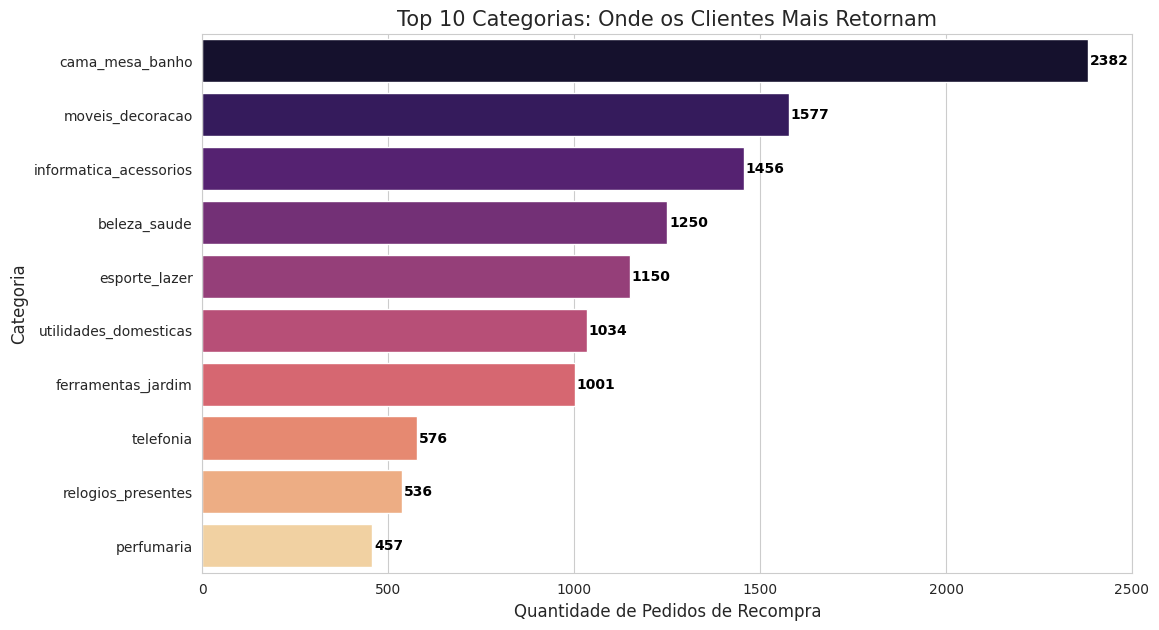

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Preparando os dados
top_recompra = ranking_recompra.reset_index()
top_recompra.columns = ['categoria', 'contagem']

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Criando o gráfico de barras
sns.barplot(data=top_recompra, x='contagem', y='categoria', palette='magma')

plt.title('Top 10 Categorias: Onde os Clientes Mais Retornam', fontsize=15)
plt.xlabel('Quantidade de Pedidos de Recompra', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

# Adicionando os valores nas barras
for i, v in enumerate(top_recompra['contagem']):
    plt.text(v + 5, i, str(v), color='black', va='center', fontweight='bold')

plt.show()

### Insights Estratégicos

Olhando para esses dados, aqui estão os três pontos fundamentais:

* O Domínio do Lar (Cama, Mesa e Banho & Móveis):

As duas categorias no topo representam quase 2.000 recompras. Isso indica que quem começa a mobiliar ou decorar a casa tende a fidelizar com a plataforma para completar o ambiente. É um comportamento de "projeto" e não apenas de "impulso".

* Recorrência vs. Necessidade:

Perfumaria aparece com força (567 recompras). Diferente de um móvel, perfumes são consumíveis. Esse é o nicho ideal para estratégias de marketing de retenção ou modelos de IA de "próxima compra provável".

* Tecnologia de Acessórios:

Informática e Acessórios e Telefonia estão no Top 10. Isso mostra que o cliente volta para comprar o periférico (o fone, o cabo, o mouse) após ter comprado o item principal.